# Load and Inspect the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the dataset
file_path = 'used_cars.csv'  # Update this path if necessary
df = pd.read_csv(file_path)

# Display first few rows and check column names
print("First few rows of the dataset:")
display(df.head())

print("\nColumn Names Before Processing:")
print(df.columns.tolist())

# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

print("\nColumn Names After Processing:")
print(df.columns.tolist())


First few rows of the dataset:


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"



Column Names Before Processing:
['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']

Column Names After Processing:
['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


# Data Preprocessing

In [2]:
# Convert price column to numeric (remove $ symbol)
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Convert mileage column to numeric (remove 'mi.' and commas)
df['milage'] = df['milage'].str.replace(' mi.', '').str.replace(',', '').astype(float)

# Extract engine size from engine column
df['engine_size'] = df['engine'].apply(lambda x: float(re.findall(r'\d+\.\d+', str(x))[0]) if re.findall(r'\d+\.\d+', str(x)) else np.nan)

# Drop original engine column (since we extracted numeric values)
df.drop(columns=['engine'], inplace=True)

# Check for missing values
print("\nMissing values in dataset:")
print(df.isnull().sum())



Missing values in dataset:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
engine_size     103
dtype: int64


# Encode Categorical Variables

In [3]:
from sklearn.preprocessing import LabelEncoder

# Define categorical columns
categorical_columns = ['brand', 'model', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

# Encode categorical variables
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le  # Store encoder for later use


# Define Price Categories (Target Variable)

In [4]:
# Define price percentiles
q1 = df['price'].quantile(0.33)  # 33rd percentile
q2 = df['price'].quantile(0.66)  # 66th percentile

# Function to categorize price
def categorize_price(price):
    if price <= q1:
        return 'Underpriced'
    elif price <= q2:
        return 'Fair Price'
    else:
        return 'Overpriced'

# Apply categorization
df['price_category'] = df['price'].apply(categorize_price)

# Encode the target variable
le_target = LabelEncoder()
df['price_category'] = le_target.fit_transform(df['price_category'])

# Show class distribution
print("\nPrice Category Distribution:")
print(df['price_category'].value_counts())



Price Category Distribution:
price_category
1    1354
2    1339
0    1316
Name: count, dtype: int64


# Feature Selection and Splitting Dataset

In [5]:
from sklearn.model_selection import train_test_split

# Define features and target
features = ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'transmission',
            'ext_col', 'int_col', 'accident', 'clean_title', 'engine_size']
target = 'price_category'

# Split dataset into training (80%) and testing (20%)
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Standardize Numerical Features

In [6]:
from sklearn.preprocessing import StandardScaler

# Define numerical columns to scale
numerical_features = ['milage', 'engine_size']

# Standardize numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])


# Train Random Forest Classifier

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# Model Predictions and Evaluation


Classification Report:
              precision    recall  f1-score   support

  Fair Price       0.76      0.75      0.75       263
  Overpriced       0.86      0.87      0.87       271
 Underpriced       0.86      0.88      0.87       268

    accuracy                           0.83       802
   macro avg       0.83      0.83      0.83       802
weighted avg       0.83      0.83      0.83       802


Confusion Matrix:


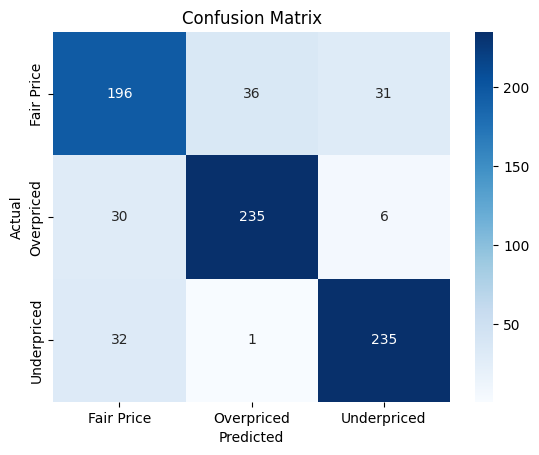


Accuracy Score: 0.830423940149626


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Make predictions
y_pred = clf.predict(X_test)

# Model Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print accuracy score
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))


# Feature Importance Visualization

<ipython-input-9-214274a066fb>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')


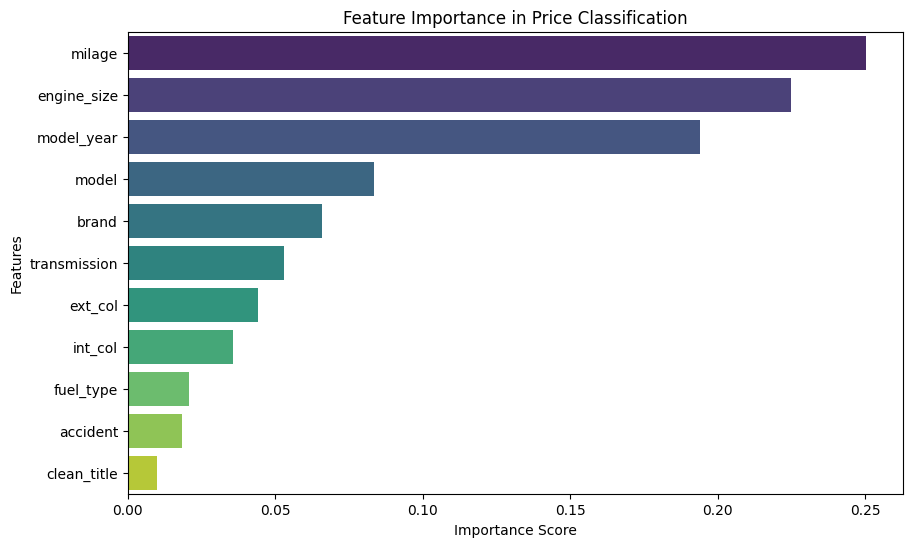

In [9]:
  # Feature Importance Plot
feature_importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance in Price Classification')
plt.show()
